# Gradient check

## Linear Regression

In [146]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [147]:
X = torch.arange(-5, 5, 1).view(-1, 1)
X_np = X.numpy()

In [148]:
func = -5 * X
Y = func + 0.4 * torch.randn(X.size())

Y_np = Y.numpy()

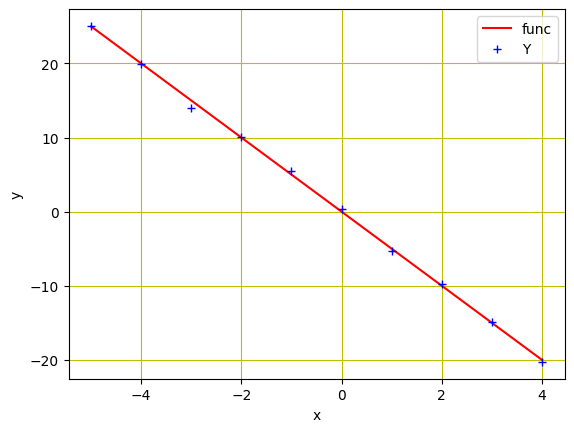

In [149]:
plt.plot(X_np, func, 'r', label="func")
plt.plot(X_np, Y_np, 'b+', label="Y")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid('True', color='y')
plt.show()

Gradient = $\frac{\partial{\text{loss func}}}{\partial{w}}$

loss func = $\sum{{(y - y^{pred})}^2}$

$y^{pred} = w * x$

In [150]:
w_np = -10.0

def forward():
  return w_np * X_np

Y_pred = forward()

# Loss function only for demonstration purpose.
# def my_loss_func():    
#   return (Y_np - Y_pred) ** 2

# (Y_np - Y_pred) is the gradient of loss function 

def my_loss_fun_grad():
  return Y_np - Y_pred

def my_grad_calc():
  return -2 * X_np * my_loss_fun_grad()

my_grad = my_grad_calc()

# print(f"X_np: {X_np}, \n Y_np: {Y_np}, \n my_grad:{my_grad}")
print(f"my_grad.sum: {my_grad.sum()}")

my_grad.sum: -853.5152673721313


Another approach for calculating derivative

We are using "h", a small value by which input changes. Hence derivative is the ratio between small change in input vs output of a function. This will also give us desired derivative.

In [151]:
def loss(w):
    Y_pred = w * X_np
    return ((Y_np - Y_pred) ** 2).sum()

h = 1e-4
w0 = -10.0
num_grad = (loss(w0 + h) - loss(w0 - h)) / (2 * h)

print(f"numerical grad: {num_grad:.3f}")


numerical grad: -853.515


### Autograd

In [152]:
w = torch.tensor(-10.0, requires_grad=True)

def fwrd(x):
  return w * x

def criterion(y_pred, y):
  return (y_pred - y) ** 2

loss = criterion(fwrd(X), Y)

loss.backward(torch.ones_like(X))

In [153]:

print(f"AutoGrad {w.grad:.3f}")
print(f"my_grad for weight: {my_grad.sum():.3f}")

AutoGrad -853.515
my_grad for weight: -853.515
